# Updating Survival Analysis (Adam's Baseline: Era 1 vs Era 2)
This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) clinical dataset to determine if patient survival outcomes have significantly changed between two distinct operational eras: 
* **Era 1:** 2010–2017 
* **Era 2:** 2018–2021

This utilizes standard **Kaplan-Meier estimates** to visualize survival probability over duration in the hospital (Days), and the **Log-Rank test** to determine statistical significance between the eras.

# Need to install decryption Libraries

In [ ]:
%pip install msoffcrypto-tool openpyxl

# Install libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import msoffcrypto
import io
import openpyxl

from pathlib import Path
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


# Get the password from env

In [16]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [17]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [18]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Unknown,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved
0,SGSIN0213,SG,SIN,2,EMS,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,...,NaN,,,,,,NaN,,,2011-02-22
1,SGSIN0218,SG,SIN,2,EMS,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,...,NaN,,,,,,NaN,,,2011-02-22
2,SGSIN6480,SG,SIN,6,EMS,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,...,NaN,,,,,,NaN,,,2012-04-18


# Prepare data and convert date columns to datetime

In [19]:
df_km = df.copy()

df['Date of Incident'] = pd.to_datetime(df['Date of Incident'],
                                        format='mixed',
                                        errors='coerce')
df_km['Date of Discharge or Death'] = pd.to_datetime(df_km['Date of Discharge or Death'],
                                                     format='mixed',
                                                     errors='coerce')

# Calculate duration in days

In [20]:
df_km['Time Days'] = (df_km['Date of Discharge or Death'] - df_km['Date of Incident']).dt.days

# Drop impossible/missing dates
df_km = df_km.dropna(subset=['Time Days']).copy()
df_km = df_km[df_km['Time Days'] >= 0]

display (df_km['Time Days'].head())

3     3.0
9     2.0
10    3.0
15    1.0
16    1.0
Name: Time Days, dtype: float64

# Define Event (1 = Died, 0 = Censored / Discharged)

In [21]:
df_km['Survival_Event'] = df_km['Patient status'].astype(str).str.contains('Dead|Died',
                                                                           case=False,
                                                                           na=False).astype(int)

display(df_km['Survival_Event'].head())

3     1
9     1
10    1
15    1
16    1
Name: Survival_Event, dtype: int64

# Creating the Eras to compare

In [22]:
df_km['Year'] = df_km['Date of Incident'].dt.year
era1_final = df_km[(df_km['Year'] >= 2010) & (df_km['Year'] <= 2017)]
era2_final = df_km[(df_km['Year'] >= 2018) & (df_km['Year'] <= 2021)]

# Print counts
print(f"Era 1 (2010-2017) valid KM patient count: {len(era1_final)}")
print(f"Era 2 (2018-2021) valid KM patient count: {len(era2_final)}\n")

Era 1 (2010-2017) valid KM patient count: 2733
Era 2 (2018-2021) valid KM patient count: 1875



# Fit and plot Kaplan-Meier Curves

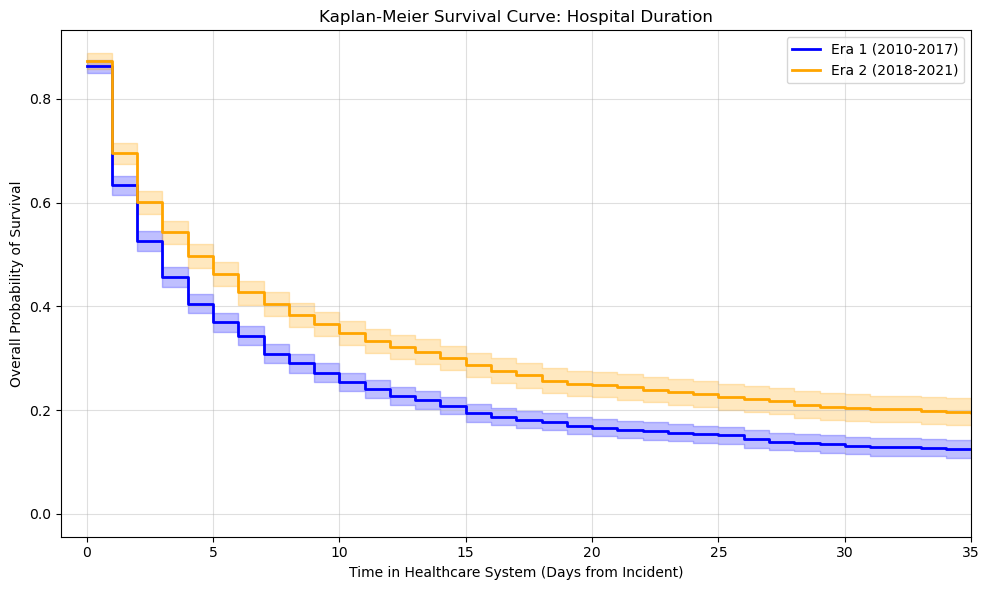

In [23]:
kmf_era1 = KaplanMeierFitter()
kmf_era2 = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

# Plot Era 1
kmf_era1.fit(durations=era1_final['Time Days'], event_observed=era1_final['Survival_Event'], label='Era 1 (2010-2017)')
kmf_era1.plot_survival_function(color='blue', linewidth=2)

# Plot Era 2
kmf_era2.fit(durations=era2_final['Time Days'], event_observed=era2_final['Survival_Event'], label='Era 2 (2018-2021)')
kmf_era2.plot_survival_function(color='orange', linewidth=2)

plt.title("Kaplan-Meier Survival Curve: Hospital Duration")
plt.xlabel('Time in Healthcare System (Days from Incident)')
plt.ylabel('Overall Probability of Survival')
plt.grid(True, alpha=0.4)
plt.xlim(-1, 35)
plt.legend()
plt.tight_layout()
plt.show()

# Log-Rank Statistical Significance Test

In [24]:
results = logrank_test(durations_A=era1_final['Time Days'], 
                       durations_B=era2_final['Time Days'], 
                       event_observed_A=era1_final['Survival_Event'], 
                       event_observed_B=era2_final['Survival_Event'])

print(f"Log-Rank Test P-value: {results.p_value:.5f}")
if results.p_value < 0.05:
    print("✅ There IS a statistically significant difference in survival between Era 1 and Era 2.")
else:
    print("❌ The difference is NOT statistically significant between Era 1 and Era 2.")

Log-Rank Test P-value: 0.00000
✅ There IS a statistically significant difference in survival between Era 1 and Era 2.
